In [1]:
%load_ext autoreload

import os, sys
import networkx as nx

sys.path.insert(0, "../")
sys.path.insert(0, "/home/j/joppich/.local/lib/python3.11/site-packages/")

%autoreload 2
from PICASO.kgraph import *
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

from collections import defaultdict, Counter

import random
random.seed(42)

import pickle

import logging
logging.basicConfig(level=logging.DEBUG)

In [2]:
kg = KGraph()

In [3]:
logging.basicConfig(level=logging.DEBUG)
kg.load_kgraph_base(
                    "../data/", TFLink=True, TFs=False, go=True, omnipath=True, opentargets=True, reactome=True, STRING=True, kegg=True, uniprot_loc=True,
                     organism="mouse",mgidiseases=True, mirtarbase=True, NPinter=True, smpdb=True, xdeathdb=True,metalinks=True,
                     hallmark_genesets="kegg_gmts/mouse/m1.all.v2023.2.Mm.symbols.gmt",
                     curated_genesets="kegg_gmts/mouse/m2.all.v2023.2.Mm.symbols.gmt"
                   )
logging.basicConfig(level=logging.WARN)

INFO:KGraph:Loading STRING Graph
INFO:load_STRING:Loading file 10090.protein.links.full.v11.5.txt
/mnt/raidbio/extproj/projekte/regulatory_networks/scripts/../PICASO/load_utils.py:568: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["score"] = subdf[use_evidences].max(axis=1)/1000
INFO:load_STRING:Loading biomart file 10090.mart_export_oct2014.txt
INFO:KGraph:Current KG DiGraph with 14024 nodes and 204792 edges
INFO:KGraph:Loading TFLink Transcription Factors Graph
INFO:load_reactome:Loading TFLINK mouse
INFO:load_reactome:Loading TFLINK mouse from ../data/TFLink_mouse.gmt
INFO:KGraph:Current KG DiGraph with 22159 nodes and 4182997 edges
INFO:KGraph:Loading GeneOntology Graph


HMS:0:00:13.069399 588,654 annotations READ: ../data/goa_mouse.gaf 
../data/go-basic.obo: fmt(1.2) rel(2023-01-01) 46,739 Terms


/mnt/raidbio/extproj/projekte/regulatory_networks/scripts/../PICASO/load_utils.py:114: DtypeWarning: Columns (12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  hgncDF = pd.read_csv(os.path.join(data_dir, genenameFile), sep="\t")
INFO:KGraph:Current KG DiGraph with 159879 nodes and 4597353 edges
INFO:KGraph:Loading Reactome Graph
INFO:load_reactome:Loading REACTOME mouse
INFO:load_reactome:Loading REACTOME mouse from ../data/kegg_gmts/mouse/m2.cp.reactome.v2023.2.Mm.symbols.gmt
INFO:KGraph:Current KG DiGraph with 161158 nodes and 4668434 edges
INFO:KGraph:Loading miRTarBase Graph
INFO:load mirtarbase:Adding mirtarbase
INFO:KGraph:Current KG DiGraph with 162382 nodes and 4709104 edges
INFO:KGraph:Loading KEGG Graph
INFO:KGraph:Current KG DiGraph with 164359 nodes and 4876330 edges
INFO:KGraph:Loading OmniPath Graph
/mnt/raidbio/extproj/projekte/regulatory_networks/scripts/../PICASO/load_utils.py:415: DtypeWarning: Columns (13,14,15,16,17) have mi

../data/uniprot_cellular_location.obo: fmt(1.2) rel(None) 563 Terms; optional_attrs(relationship xref)


INFO:KGraph:Current KG DiGraph with 307956 nodes and 6432287 edges
INFO:KGraph:Loading XDeathDB
/mnt/raidbio/extproj/projekte/regulatory_networks/scripts/../PICASO/load_utils.py:1178: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(inputFile, header=0, encoding="latin-1")
INFO:KGraph:Current KG DiGraph with 314040 nodes and 6534151 edges
INFO:KGraph:Loading MetaLinks interactions
INFO:KGraph:Current KG DiGraph with 314476 nodes and 6548143 edges


Removing 65107 singletons


In [4]:
kg.get_node_types()

Counter({'gene': 69110,
         'lncRNA;ncRNA': 60767,
         'geneset': 49735,
         'geneset;metabolic_pathway': 48641,
         'cell_death_pw;geneset': 5999,
         'disease': 4063,
         'drug': 3195,
         'miRNA;ncRNA': 3122,
         'ncRNA': 2590,
         'TF;gene': 712,
         'geneset;subcellular_location': 557,
         'metabolite_targets': 427,
         'gene;ncRNA': 250,
         'gene;lncRNA;ncRNA': 189,
         'lncRNA;miRNA;ncRNA': 7,
         'disease;geneset': 4,
         'gene;miRNA;ncRNA': 1})

In [5]:
for x in kg.kg.nodes:
    if len(kg.kg.nodes[x].get("type", [])) == 0:
        print(x, kg.kg.nodes[x])
        

In [6]:
logging.basicConfig(level=logging.WARN)

In [7]:
kg.get_edge_between_type()

Counter({('TF;gene', 'gene'): 3855201,
         ('miRNA;ncRNA', 'gene'): 568729,
         ('gene', 'geneset'): 540476,
         ('lncRNA;ncRNA', 'gene'): 485464,
         ('gene', 'geneset;metabolic_pathway'): 306014,
         ('gene', 'gene'): 243980,
         ('TF;gene', 'TF;gene'): 172350,
         ('gene', 'cell_death_pw;geneset'): 87276,
         ('geneset', 'geneset'): 74928,
         ('gene', 'geneset;subcellular_location'): 50750,
         ('TF;gene', 'geneset'): 37044,
         ('disease', 'drug'): 35017,
         ('gene', 'TF;gene'): 17319,
         ('gene', 'metabolite_targets'): 13024,
         ('TF;gene', 'cell_death_pw;geneset'): 12222,
         ('gene', 'drug'): 7869,
         ('gene', 'lncRNA;ncRNA'): 4761,
         ('gene', 'disease'): 3985,
         ('miRNA;ncRNA', 'gene;ncRNA'): 3852,
         ('ncRNA', 'gene'): 3836,
         ('gene', 'ncRNA'): 3807,
         ('lncRNA;ncRNA', 'gene;ncRNA'): 2852,
         ('miRNA;ncRNA', 'TF;gene'): 2623,
         ('gene;ncRNA', 'ge

In [8]:
kg.get_node_types()

Counter({'gene': 69110,
         'lncRNA;ncRNA': 60767,
         'geneset': 49735,
         'geneset;metabolic_pathway': 48641,
         'cell_death_pw;geneset': 5999,
         'disease': 4063,
         'drug': 3195,
         'miRNA;ncRNA': 3122,
         'ncRNA': 2590,
         'TF;gene': 712,
         'geneset;subcellular_location': 557,
         'metabolite_targets': 427,
         'gene;ncRNA': 250,
         'gene;lncRNA;ncRNA': 189,
         'lncRNA;miRNA;ncRNA': 7,
         'disease;geneset': 4,
         'gene;miRNA;ncRNA': 1})

In [9]:
kg.get_edge_types()

Counter({'activates': 4113101,
         'interacts': 1317197,
         'relevant_in': 643300,
         'part_of': 360469,
         'represses': 56682,
         'affected_by': 35051,
         'target_of': 22343})

In [10]:
kg.get_edge_types(field="source")

Counter({'TFlink': 3935525,
         'npinter5': 1049651,
         'GeneOntology': 414356,
         'smpdb': 306446,
         'STRING': 182992,
         'kegg': 167226,
         'omnipath': 165695,
         'xdeathdb': 104822,
         'reactome': 71081,
         'uniprot_celloc': 47992,
         'opentargets': 43402,
         'mirtarbase': 40666,
         'metalinks': 13992,
         'MGI_DO': 4297})

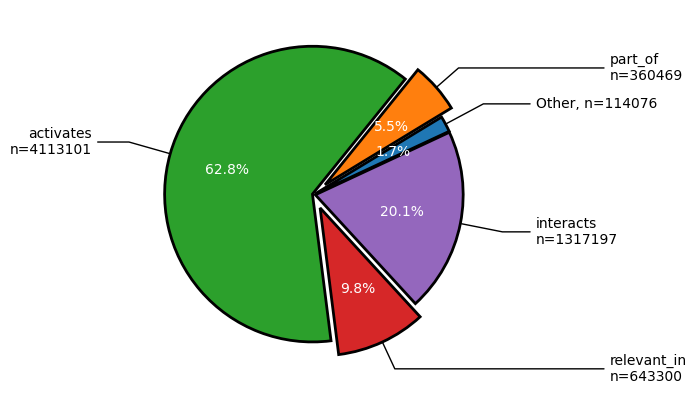

In [21]:
kg.plot_edge_types(field="type")

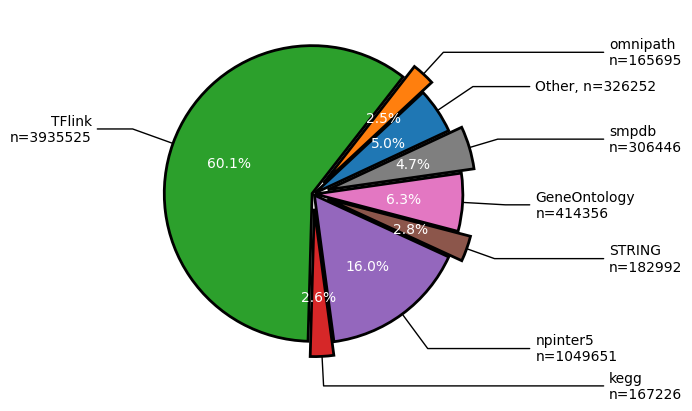

In [12]:
kg.plot_edge_types(field="source")

In [13]:
kg.get_edge_edge_types()

Counter({('TF;gene', 'gene', 'activates'): 3798591,
         ('miRNA;ncRNA', 'gene', 'interacts'): 530511,
         ('lncRNA;ncRNA', 'gene', 'interacts'): 485464,
         ('gene', 'geneset;metabolic_pathway', 'relevant_in'): 306014,
         ('gene', 'geneset', 'part_of'): 226857,
         ('gene', 'geneset', 'relevant_in'): 212322,
         ('gene', 'gene', 'interacts'): 198421,
         ('TF;gene', 'TF;gene', 'activates'): 165722,
         ('gene', 'geneset', 'activates'): 101297,
         ('gene', 'cell_death_pw;geneset', 'relevant_in'): 87276,
         ('geneset', 'geneset', 'part_of'): 74928,
         ('TF;gene', 'gene', 'interacts'): 52676,
         ('gene', 'geneset;subcellular_location', 'part_of'): 45869,
         ('miRNA;ncRNA', 'gene', 'represses'): 38218,
         ('gene', 'gene', 'activates'): 36079,
         ('disease', 'drug', 'affected_by'): 35017,
         ('TF;gene', 'geneset', 'relevant_in'): 18789,
         ('gene', 'metabolite_targets', 'target_of'): 13024,
      

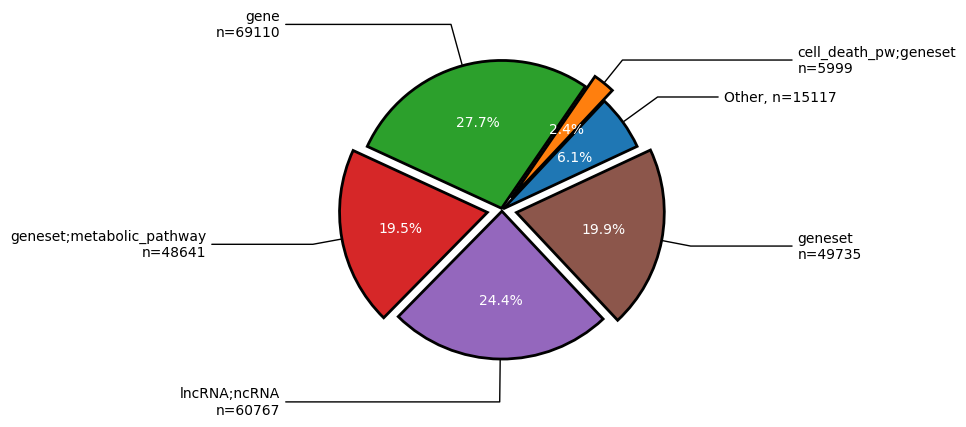

In [14]:
kg.plot_node_types()

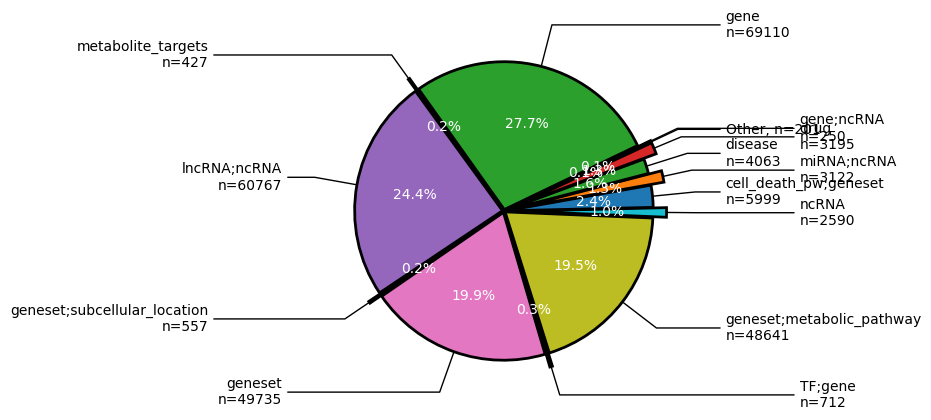

In [15]:
kg.plot_node_types(show_threshold=0.001)

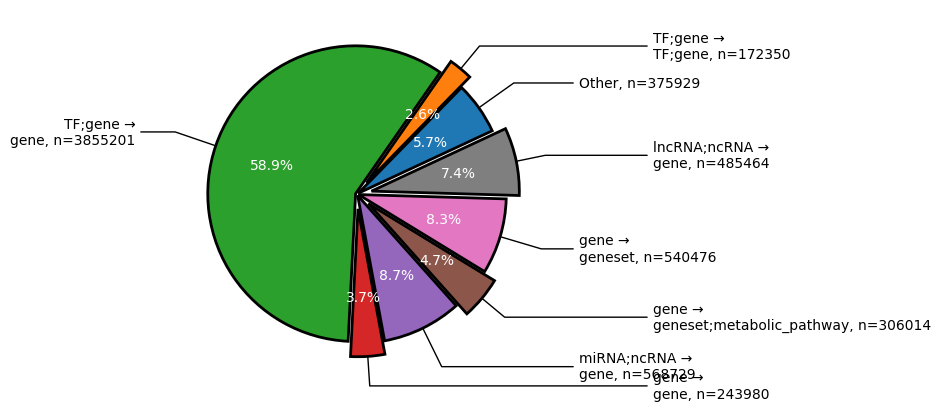

In [16]:
kg.plot_edge_between_types()

In [17]:
print(kg.kg)

DiGraph with 249369 nodes and 6548143 edges


In [18]:
for x in kg.kg.nodes:
    if "gene" in kg.kg.nodes[x]["type"] and "miRNA" in kg.kg.nodes[x]["type"]:
        print(x, kg.kg.nodes[x])

AC009336 {'id': '-', 'name': 'AC009336', 'type': {'ncRNA', 'miRNA', 'gene'}, 'biotype': 'miRNA', 'score': 0, 'source': 'npinter5'}


In [19]:
kg.save_kgraph("../data/picaso_network_mouse.out")

INFO:KGraph:Saving KG ../data/picaso_network_mouse.out
